# Interpretable Forecasting with N-BEATS

**Docker image**: `ml4t-gpu`

This notebook implements the N-BEATS architecture from scratch in PyTorch,
focusing on its interpretable configuration that decomposes forecasts into
trend and seasonality components.

**Learning Objectives**:
- Implement N-BEATS block structure with doubly-residual connections
- Understand the interpretable basis functions (polynomial trend, Fourier seasonality)
- Visualize decomposed forecast components
- Compare interpretable vs. generic configurations

**Book Reference**: Chapter 13, Section 13.2 (Decomposition: N-BEATS).
Based on Oreshkin et al. (2020), *N-BEATS: Neural Basis Expansion Analysis
for Interpretable Time Series Forecasting*.

**Prerequisites**: ETF price data (via `load_etfs()` canonical loader)

In [1]:
"""Interpretable Forecasting with N-BEATS — decompose forecasts into trend and seasonality components."""

import warnings
from datetime import datetime

import numpy as np
import plotly.graph_objects as go
import polars as pl
import torch
import torch.nn as nn
from ml4t.diagnostic.metrics import pooled_ic
from plotly.subplots import make_subplots

from data import load_etfs
from utils.reproducibility import set_global_seeds

warnings.filterwarnings("ignore")

In [2]:
SEED = 42
LOOKBACK = 60
HORIZON = 10
HIDDEN_SIZE = 256
N_BLOCKS = 3
N_LAYERS = 4
EPOCHS = 50
BATCH_SIZE = 32
START_DATE = "2015-01-01"

In [3]:
DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using device: {DEVICE}")

set_global_seeds(SEED)

Using device: cuda


## Data Preparation

N-BEATS operates on univariate time series. We use SPY close prices
to demonstrate trend and seasonality decomposition.

In [4]:
etf_df = load_etfs()

start_dt = datetime.fromisoformat(START_DATE)

spy_data = (
    etf_df.filter((pl.col("symbol") == "SPY") & (pl.col("timestamp") >= start_dt))
    .sort("timestamp")
    .select(["timestamp", "close"])
)

prices = spy_data["close"].to_numpy().astype(np.float32)
timestamps = spy_data["timestamp"].to_numpy()

# Train/val/test split sizes (70/15/15) defined here so normalization can use
# training-window stats only — no leakage from validation or test prices.
n_sequences = len(prices) - LOOKBACK - HORIZON + 1
train_seq_end = int(n_sequences * 0.70)
val_seq_end = int(n_sequences * 0.85)

# The last training sequence consumes prices up to and including index
# train_seq_end + LOOKBACK + HORIZON - 2; slice prices[:train_price_cutoff]
# (exclusive upper bound) covers exactly that range without leaking val/test
# prices into the z-score statistics.
train_price_cutoff = train_seq_end + LOOKBACK + HORIZON - 1
price_mean = prices[:train_price_cutoff].mean()
price_std = prices[:train_price_cutoff].std()
prices_norm = (prices - price_mean) / price_std

print(f"SPY data: {len(prices)} observations")
print(f"Date range: {timestamps[0]} to {timestamps[-1]}")
print(f"Normalization fit on prices[:{train_price_cutoff}] (training window only)")

SPY data: 2766 observations
Date range: 2015-01-02 to 2025-12-31
Normalization fit on prices[:1956] (training window only)


## Create Sequences

N-BEATS takes a lookback window as input and produces a forecast horizon.

In [5]:
def create_univariate_sequences(data, lookback, horizon):
    """Create (input, target) pairs for univariate forecasting."""
    X, y = [], []
    for i in range(len(data) - lookback - horizon + 1):
        X.append(data[i : i + lookback])
        y.append(data[i + lookback : i + lookback + horizon])
    return np.array(X, dtype=np.float32), np.array(y, dtype=np.float32)


X, y = create_univariate_sequences(prices_norm, LOOKBACK, HORIZON)
print(f"Sequences: X={X.shape}, y={y.shape}")

X_train, y_train = X[:train_seq_end], y[:train_seq_end]
X_val, y_val = X[train_seq_end:val_seq_end], y[train_seq_end:val_seq_end]
X_test, y_test = X[val_seq_end:], y[val_seq_end:]

print(f"Train: {len(X_train)}, Val: {len(X_val)}, Test: {len(X_test)}")

Sequences: X=(2697, 60), y=(2697, 10)
Train: 1887, Val: 405, Test: 405


## N-BEATS Block

Each block takes a lookback window as input and produces two outputs:
- **Backcast**: reconstruction of the input (for residual connections)
- **Forecast**: prediction of the future horizon

The interpretable version uses constrained basis functions:
- **Trend stack**: polynomial basis (degree 2-3)
- **Seasonality stack**: Fourier basis

### Basis Expansion Formula

The forecast is generated via basis expansion (Section 13.2):

$$\hat{y} = \sum_{i=1}^{|\theta_f|} \theta_{f,i} \cdot g_{f,i}$$

In the code below:
- `theta_f` (from `self.theta_f(h)`) = learned expansion coefficients
- `T_fore` / `S_fore` = pre-computed basis matrices ($g_f$ vectors)
- `torch.einsum("bp,tp->bt", theta_f, T_fore)` = the weighted sum above

For trend, $g_f = [1, t, t^2, t^3]$ (polynomial); for seasonality,
$g_f = [\sin(2\pi ft), \cos(2\pi ft)]$ (Fourier harmonics).

In [6]:
class NBEATSBlock(nn.Module):
    """Single N-BEATS block with shared FC stack and separate basis projections."""

    def __init__(self, lookback, horizon, hidden_size, n_layers, basis_type="generic"):
        super().__init__()
        self.lookback = lookback
        self.horizon = horizon
        self.basis_type = basis_type

        # Shared fully-connected stack
        layers = [nn.Linear(lookback, hidden_size), nn.ReLU()]
        for _ in range(n_layers - 1):
            layers.extend([nn.Linear(hidden_size, hidden_size), nn.ReLU()])
        self.fc_stack = nn.Sequential(*layers)

        if basis_type == "trend":
            # Polynomial basis: coefficients → polynomial evaluation
            self.poly_degree = 3
            self.theta_b = nn.Linear(hidden_size, self.poly_degree + 1)
            self.theta_f = nn.Linear(hidden_size, self.poly_degree + 1)
            # Pre-compute time vectors
            t_back = torch.linspace(0, 1, lookback).unsqueeze(0)
            t_fore = torch.linspace(0, 1, horizon).unsqueeze(0)
            self.register_buffer(
                "T_back",
                torch.stack([t_back**i for i in range(self.poly_degree + 1)], dim=-1).squeeze(0),
            )
            self.register_buffer(
                "T_fore",
                torch.stack([t_fore**i for i in range(self.poly_degree + 1)], dim=-1).squeeze(0),
            )

        elif basis_type == "seasonality":
            # Fourier basis: coefficients → harmonic evaluation
            self.n_harmonics = 5
            n_coeffs = 2 * self.n_harmonics
            self.theta_b = nn.Linear(hidden_size, n_coeffs)
            self.theta_f = nn.Linear(hidden_size, n_coeffs)
            # Pre-compute Fourier basis
            t_back = torch.linspace(0, 1, lookback).unsqueeze(0)
            t_fore = torch.linspace(0, 1, horizon).unsqueeze(0)
            freqs = torch.arange(1, self.n_harmonics + 1).float()
            self.register_buffer("S_back", self._fourier_basis(t_back, freqs))
            self.register_buffer("S_fore", self._fourier_basis(t_fore, freqs))

        else:  # generic
            self.theta_b = nn.Linear(hidden_size, lookback)
            self.theta_f = nn.Linear(hidden_size, horizon)

    @staticmethod
    def _fourier_basis(t, freqs):
        """Create Fourier basis matrix [sin(2pi*f*t), cos(2pi*f*t)]."""
        # t: (1, T), freqs: (H,) → output: (T, 2H)
        t = t.squeeze(0).unsqueeze(-1)  # (T, 1)
        angles = 2 * np.pi * t * freqs.unsqueeze(0)  # (T, H)
        return torch.cat([torch.sin(angles), torch.cos(angles)], dim=-1)  # (T, 2H)

    def forward(self, x):
        h = self.fc_stack(x)

        if self.basis_type == "trend":
            theta_b = self.theta_b(h)  # (batch, poly_degree+1)
            theta_f = self.theta_f(h)
            backcast = torch.einsum("bp,tp->bt", theta_b, self.T_back)
            forecast = torch.einsum("bp,tp->bt", theta_f, self.T_fore)

        elif self.basis_type == "seasonality":
            theta_b = self.theta_b(h)  # (batch, 2*n_harmonics)
            theta_f = self.theta_f(h)
            backcast = torch.einsum("bh,th->bt", theta_b, self.S_back)
            forecast = torch.einsum("bh,th->bt", theta_f, self.S_fore)

        else:  # generic
            backcast = self.theta_b(h)
            forecast = self.theta_f(h)

        return backcast, forecast

## N-BEATS Model

The full model stacks multiple blocks with **doubly-residual** connections:
each block processes the residual from previous blocks (input minus backcast).

In [7]:
class NBEATS(nn.Module):
    """N-BEATS with configurable stacks (interpretable or generic)."""

    def __init__(self, lookback, horizon, hidden_size, n_blocks, n_layers, interpretable=True):
        super().__init__()
        self.blocks = nn.ModuleList()

        if interpretable:
            # Trend stack + Seasonality stack (N-BEATS-I)
            for _ in range(n_blocks):
                self.blocks.append(NBEATSBlock(lookback, horizon, hidden_size, n_layers, "trend"))
            for _ in range(n_blocks):
                self.blocks.append(
                    NBEATSBlock(lookback, horizon, hidden_size, n_layers, "seasonality")
                )
        else:
            # All generic blocks (N-BEATS-G)
            for _ in range(n_blocks * 2):
                self.blocks.append(NBEATSBlock(lookback, horizon, hidden_size, n_layers, "generic"))

    def forward(self, x):
        residual = x
        forecast = torch.zeros(x.shape[0], self.blocks[0].horizon, device=x.device)

        block_forecasts = []
        for block in self.blocks:
            backcast, block_forecast = block(residual)
            residual = residual - backcast  # Doubly-residual: update input
            forecast = forecast + block_forecast  # Accumulate forecasts
            block_forecasts.append(block_forecast)

        return forecast, block_forecasts

## Training

In [8]:
def train_nbeats(model, X_train, y_train, X_val, y_val, epochs, batch_size, lr=1e-3):
    """Train N-BEATS with early stopping."""
    optimizer = torch.optim.Adam(model.parameters(), lr=lr)
    criterion = nn.MSELoss()

    X_tr = torch.FloatTensor(X_train).to(DEVICE)
    y_tr = torch.FloatTensor(y_train).to(DEVICE)
    X_v = torch.FloatTensor(X_val).to(DEVICE)
    y_v = torch.FloatTensor(y_val).to(DEVICE)

    best_val_loss = float("inf")
    best_state = None
    patience = 7
    patience_counter = 0

    for epoch in range(epochs):
        model.train()
        indices = torch.randperm(len(X_tr))
        epoch_loss = 0.0
        n_batches = 0

        for i in range(0, len(indices), batch_size):
            batch_idx = indices[i : i + batch_size]
            forecast, _ = model(X_tr[batch_idx])
            loss = criterion(forecast, y_tr[batch_idx])

            optimizer.zero_grad()
            loss.backward()
            torch.nn.utils.clip_grad_norm_(model.parameters(), 1.0)  # Prevent exploding gradients
            optimizer.step()
            epoch_loss += loss.item()
            n_batches += 1

        model.eval()
        with torch.no_grad():
            val_forecast, _ = model(X_v)
            val_loss = criterion(val_forecast, y_v).item()

        if val_loss < best_val_loss:
            best_val_loss = val_loss
            best_state = {k: v.cpu().clone() for k, v in model.state_dict().items()}
            patience_counter = 0
        else:
            patience_counter += 1

        if (epoch + 1) % 10 == 0 or epoch == 0:
            print(
                f"  Epoch {epoch + 1}/{epochs}: train={epoch_loss / n_batches:.6f}, val={val_loss:.6f}"
            )

        if patience_counter >= patience:
            print(f"  Early stopping at epoch {epoch + 1}")
            break

    if best_state is not None:
        model.load_state_dict(best_state)
    return model

## Train N-BEATS Interpretable

In [9]:
print("Training N-BEATS-I (interpretable)...")
nbeats_i = NBEATS(LOOKBACK, HORIZON, HIDDEN_SIZE, N_BLOCKS, N_LAYERS, interpretable=True).to(DEVICE)
n_params = sum(p.numel() for p in nbeats_i.parameters())
print(f"  Parameters: {n_params:,}")

nbeats_i = train_nbeats(nbeats_i, X_train, y_train, X_val, y_val, EPOCHS, BATCH_SIZE)

Training N-BEATS-I (interpretable)...


  Parameters: 1,299,540


  Epoch 1/50: train=0.053924, val=0.022595


  Epoch 10/50: train=0.005104, val=0.017549


  Early stopping at epoch 18


## Train N-BEATS Generic

In [10]:
print("\nTraining N-BEATS-G (generic)...")
nbeats_g = NBEATS(LOOKBACK, HORIZON, HIDDEN_SIZE, N_BLOCKS, N_LAYERS, interpretable=False).to(
    DEVICE
)
n_params_g = sum(p.numel() for p in nbeats_g.parameters())
print(f"  Parameters: {n_params_g:,}")

nbeats_g = train_nbeats(nbeats_g, X_train, y_train, X_val, y_val, EPOCHS, BATCH_SIZE)


Training N-BEATS-G (generic)...
  Parameters: 1,385,892


  Epoch 1/50: train=0.081077, val=0.021356


  Epoch 10/50: train=0.007305, val=0.014597


  Early stopping at epoch 17


## Evaluation

We compare N-BEATS-I (interpretable) vs. N-BEATS-G (generic) using two
metrics: MSE (point-forecast accuracy) and a price-path Spearman rank
correlation between mean predicted and mean realised price levels over the
10-step horizon. This is a temporal rank metric on one SPY series, not the
cross-sectional IC used elsewhere in Chapter 13.

In [11]:
X_test_t = torch.FloatTensor(X_test).to(DEVICE)

nbeats_i.eval()
nbeats_g.eval()

with torch.no_grad():
    pred_i, block_forecasts_i = nbeats_i(X_test_t)
    pred_g, _ = nbeats_g(X_test_t)

pred_i = pred_i.cpu().numpy()
pred_g = pred_g.cpu().numpy()

In [12]:
# Compute IC on mean forecast vs mean actual (per sample)
pred_i_mean = pred_i.mean(axis=1)
pred_g_mean = pred_g.mean(axis=1)
y_test_mean = y_test.mean(axis=1)

ic_i = pooled_ic(pred_i_mean, y_test_mean)
ic_g = pooled_ic(pred_g_mean, y_test_mean)

mse_i = np.mean((pred_i - y_test) ** 2)
mse_g = np.mean((pred_g - y_test) ** 2)

comparison_df = pl.DataFrame(
    {
        "Model": ["N-BEATS-I", "N-BEATS-G"],
        "MSE": [mse_i, mse_g],
        "Price-path Spearman ρ": [ic_i, ic_g],
    }
)
comparison_df

Model,MSE,Price-path Spearman ρ
str,f32,f64
"""N-BEATS-I""",0.145775,0.949841
"""N-BEATS-G""",0.091516,0.958699


**Interpretation**: on this single SPY split, N-BEATS-G's MSE is lower than
N-BEATS-I (see table) and its price-path Spearman ρ is marginally higher —
both gaps are point estimates with no fold-level dispersion reported here.
The interpretable variant constrains its forecasts to polynomial trend +
Fourier seasonality; the generic variant learns arbitrary basis functions
and pays for that flexibility with lower interpretability. Whether either
gap survives walk-forward evaluation across instruments is not tested in
this notebook; the practical tradeoff here is interpretability versus
point-forecast accuracy on one univariate price series.

## Component Decomposition

The key advantage of N-BEATS-I: we can examine which blocks contribute
trend vs. seasonality to the forecast.

In [13]:
# Extract block-level forecasts for a sample
sample_idx = len(X_test) // 2
block_preds = [bf[sample_idx].cpu().numpy() for bf in block_forecasts_i]

# First N_BLOCKS are trend, last N_BLOCKS are seasonality
trend_forecast = sum(block_preds[:N_BLOCKS])
seasonal_forecast = sum(block_preds[N_BLOCKS:])

**Denormalization**: The trend component gets the mean added back (it captures
the price level), while seasonality is zero-centered (periodic deviations around
the trend). The combined forecast = Trend + Seasonality in original price space.

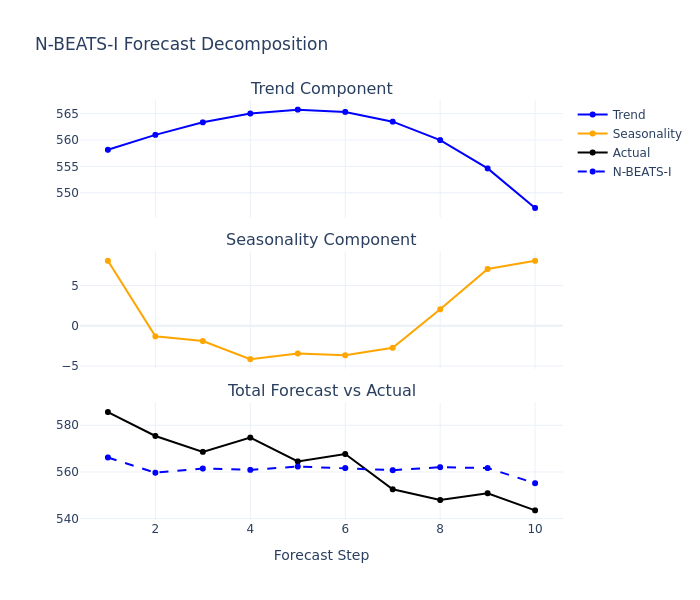

In [14]:
trend_denorm = trend_forecast * price_std + price_mean
seasonal_denorm = seasonal_forecast * price_std  # Zero-centered
total_denorm = pred_i[sample_idx] * price_std + price_mean
actual_denorm = y_test[sample_idx] * price_std + price_mean

x_axis = list(range(1, HORIZON + 1))

fig = make_subplots(
    rows=3,
    cols=1,
    subplot_titles=["Trend Component", "Seasonality Component", "Total Forecast vs Actual"],
    shared_xaxes=True,
    vertical_spacing=0.08,
)

fig.add_trace(
    go.Scatter(x=x_axis, y=trend_denorm, name="Trend", line=dict(color="blue")), row=1, col=1
)
fig.add_trace(
    go.Scatter(x=x_axis, y=seasonal_denorm, name="Seasonality", line=dict(color="orange")),
    row=2,
    col=1,
)
fig.add_trace(
    go.Scatter(x=x_axis, y=actual_denorm, name="Actual", line=dict(color="black", width=2)),
    row=3,
    col=1,
)
fig.add_trace(
    go.Scatter(x=x_axis, y=total_denorm, name="N-BEATS-I", line=dict(color="blue", dash="dash")),
    row=3,
    col=1,
)

fig.update_layout(title="N-BEATS-I Forecast Decomposition", template="plotly_white", height=600)
fig.update_xaxes(title_text="Forecast Step", row=3, col=1)
fig.show()

## Backcast Visualization

The backcast represents what each block has "understood" about the input.
The residual (input minus backcast) is passed to the next block, forcing
progressively finer pattern extraction.

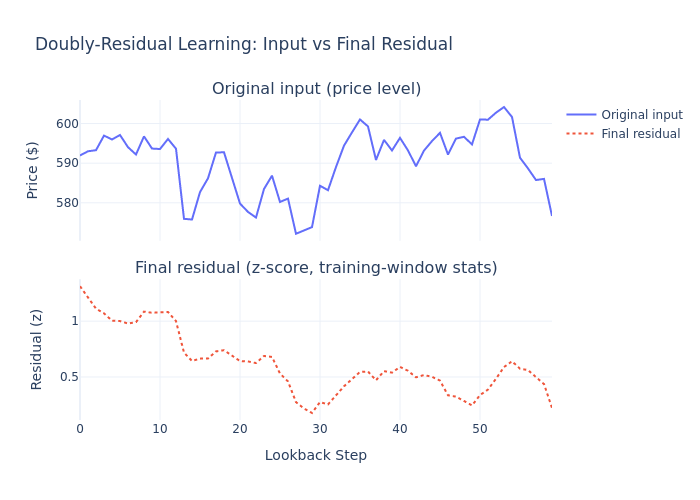

In [15]:
# Compute block-level backcasts for the same test sample
sample_input = torch.FloatTensor(X_test[sample_idx : sample_idx + 1]).to(DEVICE)
nbeats_i.eval()

with torch.no_grad():
    residual = sample_input.clone()
    backcasts = []
    for block in nbeats_i.blocks:
        backcast, _ = block(residual)
        backcasts.append(backcast.cpu().numpy().flatten())
        residual = residual - backcast

# Denormalize the input back to price level; the residual stays in z-score
# units because adding the training-window mean would shift "structure not yet
# captured" onto the price scale and conflate it with the input curve.
input_denorm = X_test[sample_idx] * price_std + price_mean
residual_z = residual.cpu().numpy().flatten()

x_back = list(range(LOOKBACK))

fig_bc = make_subplots(
    rows=2,
    cols=1,
    subplot_titles=[
        "Original input (price level)",
        "Final residual (z-score, training-window stats)",
    ],
    shared_xaxes=True,
    vertical_spacing=0.12,
)
fig_bc.add_trace(
    go.Scatter(x=x_back, y=input_denorm, name="Original input", line=dict(width=2)), row=1, col=1
)
fig_bc.add_trace(
    go.Scatter(x=x_back, y=residual_z, name="Final residual", line=dict(dash="dot")), row=2, col=1
)
fig_bc.update_xaxes(title_text="Lookback Step", row=2, col=1)
fig_bc.update_yaxes(title_text="Price ($)", row=1, col=1)
fig_bc.update_yaxes(title_text="Residual (z)", row=2, col=1)
fig_bc.update_layout(
    title="Doubly-Residual Learning: Input vs Final Residual",
    template="plotly_white",
    height=500,
)
fig_bc.show()

**Interpretation**: The final residual should be close to noise — the trend
and seasonality stacks have extracted the structured signal. If significant
structure remains, the model may need more blocks or a different configuration.

## Lookback Sensitivity

N-BEATS is sensitive to the lookback-to-horizon ratio. Too short a lookback
starves the decomposition of context; very long lookbacks can introduce noise.

In [16]:
lookback_values = [20, 40, 60, 120]
sensitivity_results = []

for lb in lookback_values:
    # Re-normalize per-lookback using training-window-only stats: the training
    # sequence range and therefore the safe normalization cutoff both depend on lb.
    n_s = len(prices) - lb - HORIZON + 1
    tr_end = int(n_s * 0.70)
    val_end = int(n_s * 0.85)
    cutoff_s = tr_end + lb + HORIZON - 1
    pm_s = prices[:cutoff_s].mean()
    ps_s = prices[:cutoff_s].std()
    prices_norm_s = (prices - pm_s) / ps_s

    X_s, y_s = create_univariate_sequences(prices_norm_s, lb, HORIZON)

    model_s = NBEATS(lb, HORIZON, HIDDEN_SIZE, N_BLOCKS, N_LAYERS, interpretable=True).to(DEVICE)
    model_s = train_nbeats(
        model_s,
        X_s[:tr_end],
        y_s[:tr_end],
        X_s[tr_end:val_end],
        y_s[tr_end:val_end],
        EPOCHS,
        BATCH_SIZE,
    )

    model_s.eval()
    with torch.no_grad():
        pred_s, _ = model_s(torch.FloatTensor(X_s[val_end:]).to(DEVICE))
    pred_s = pred_s.cpu().numpy()
    y_s_test = y_s[val_end:]

    mse_s = float(np.mean((pred_s - y_s_test) ** 2))
    ic_s = pooled_ic(pred_s.mean(axis=1), y_s_test.mean(axis=1))
    sensitivity_results.append(
        {"Lookback": lb, "Ratio": lb / HORIZON, "MSE": mse_s, "Price-path Spearman ρ": ic_s}
    )
    print(f"  Lookback={lb} (ratio={lb / HORIZON:.1f}): MSE={mse_s:.6f}, ρ={ic_s:.4f}")

sensitivity_df = pl.DataFrame(sensitivity_results)
sensitivity_df

  Epoch 1/50: train=0.046546, val=0.029508


  Epoch 10/50: train=0.008255, val=0.035475
  Early stopping at epoch 10
  Lookback=20 (ratio=2.0): MSE=0.059544, ρ=0.9616


  Epoch 1/50: train=0.059431, val=0.014275


  Early stopping at epoch 8
  Lookback=40 (ratio=4.0): MSE=0.064010, ρ=0.9553


  Epoch 1/50: train=0.061995, val=0.038782


  Epoch 10/50: train=0.004660, val=0.014490


  Early stopping at epoch 12
  Lookback=60 (ratio=6.0): MSE=0.084133, ρ=0.9567


  Epoch 1/50: train=0.056915, val=0.044144


  Epoch 10/50: train=0.003181, val=0.052241
  Early stopping at epoch 10
  Lookback=120 (ratio=12.0): MSE=0.180588, ρ=0.8920


Lookback,Ratio,MSE,Price-path Spearman ρ
i64,f64,f64,f64
20,2.0,0.059544,0.961584
40,4.0,0.06401,0.955278
60,6.0,0.084133,0.95669
120,12.0,0.180588,0.891978


**Finding**: ratios in the 2–6× range recommended by Oreshkin et al. all
produce a price-path Spearman ρ ≈ 0.96 on this SPY split (0.962 at 2×,
0.955 at 4×, 0.957 at 6×). The 12× ratio drops to 0.892 and MSE rises from
~0.07 (mean across 2–6×) to 0.181 — a ~2.6× increase — consistent with
longer input windows adding noise without compensating signal. The optimal
ratio depends on the frequency and memory structure of the data; this
notebook does not search beyond a single equity index.

## sktime Alternative

sktime wraps PyTorch Forecasting's N-BEATS implementation, providing the same
architecture via a unified `fit()`/`predict()` API.

**Dependency note**: sktime's neural forecasters require `neuralforecast`, which
depends on `ray` — and ray does not yet support Python 3.14
([ray-project/ray#56434](https://github.com/ray-project/ray/issues/56434)).
Once ray adds 3.14 wheels, install via `uv pip install neuralforecast`
and uncomment the demo below.

In [17]:
# import pandas as pd
# from sktime.forecasting.pytorchforecasting import PytorchForecastingNBeats
#
# # Prepare univariate series for sktime
# spy_close = spy_data.to_pandas().set_index("timestamp")["close"].dropna()
# split = int(len(spy_close) * 0.8)
# y_train_sk = spy_close.iloc[:split]
# y_test_sk = spy_close.iloc[split : split + HORIZON]
#
# forecaster = PytorchForecastingNBeats(
#     max_prediction_length=HORIZON,
#     max_encoder_length=LOOKBACK,
#     max_epochs=min(EPOCHS, 10),
#     trainer_kwargs={"enable_progress_bar": False, "accelerator": "auto"},
# )
# forecaster.fit(y_train_sk)
# y_pred_sk = forecaster.predict(fh=list(range(1, HORIZON + 1)))
#
# mae_sk = float(np.mean(np.abs(y_test_sk.values - y_pred_sk.values)))
# print(f"sktime PytorchForecastingNBeats: MAE = {mae_sk:.4f}")

## Key Takeaways

1. **Doubly-residual architecture**: Each block refines the input residual AND
   accumulates its forecast contribution
2. **Interpretable decomposition**: Polynomial trend + Fourier seasonality stacks
   produce human-readable components
3. **Generic mode**: Learns arbitrary basis functions, potentially more accurate
   but loses interpretability
4. **No feature engineering**: N-BEATS works directly on the raw price series;
   forecast targets are price levels, so the price-path Spearman ρ reported
   here is a temporal rank metric, not a cross-sectional return IC
5. **Lookback-to-horizon ratio**: Performance is sensitive to this ratio;
   values of 2-7 work well in practice
6. **sktime wraps PyTorch Forecasting** for production N-BEATS in 3 lines

**Caveat**: Results on a single equity index (SPY) are not generalizable —
benchmark on your specific dataset before drawing architecture conclusions.

**Next**: See `03_great_debate` for the Linear vs. Transformer controversy.